In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [2]:
crime_df = pd.read_csv(r'D:\WesternMichiganUni\GIS_Programming\miniproject\Little_Rock_Crime_2020_2026.csv')
crime_df.head()
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81629 entries, 0 to 81628
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   INCIDENT_DATE        81629 non-null  object 
 1   INCIDENT_NUMBER      81629 non-null  object 
 2   LOCATION_DISTRICT    81516 non-null  float64
 3   OFFENSE_CODE         81629 non-null  object 
 4   OFFENSE_DESCRIPTION  81629 non-null  object 
 5   WEAPON_TYPE          20088 non-null  object 
 6   INCIDENT_LOCATION    81629 non-null  object 
 7   CITY                 81629 non-null  object 
 8   STATE                81629 non-null  object 
 9   ZIP                  81629 non-null  int64  
 10  LATITUDE             76437 non-null  float64
 11  LONGITUDE            76437 non-null  float64
 12  Location 1           76437 non-null  object 
 13  Offense Status       81601 non-null  object 
 14  Year                 81629 non-null  int64  
dtypes: float64(3), int64(2), object(10)


In [4]:
crime_df["INCIDENT_DATE"] = pd.to_datetime(crime_df["INCIDENT_DATE"], errors="coerce")

crime_df = crime_df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

crime_df = crime_df[
    (crime_df["LATITUDE"].between(34, 35)) &
    (crime_df["LONGITUDE"].between(-93, -92))
].copy()

In [5]:
crime_df["Month"] = crime_df["INCIDENT_DATE"].dt.month
crime_df["Hour"] = crime_df["INCIDENT_DATE"].dt.hour
crime_df["DayOfWeek"] = crime_df["INCIDENT_DATE"].dt.day_name()

In [6]:
geometry = gpd.points_from_xy(crime_df["LONGITUDE"], crime_df["LATITUDE"])
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry, crs="EPSG:4326")
crime_gdf.head()

,INCIDENT_DATE,INCIDENT_NUMBER,LOCATION_DISTRICT,OFFENSE_CODE,OFFENSE_DESCRIPTION,WEAPON_TYPE,INCIDENT_LOCATION,CITY,STATE,ZIP,LATITUDE,LONGITUDE,Location 1,Offense Status,Year,Month,Hour,DayOfWeek,geometry
0,2026-01-19 23:20:00,2026-008338,61.0,23H,ALL OTHER LARCENY,NaN,7200 W 12TH ST,LITTLE ROCK,AR,72204,34.742472,-92.355167,"(34.742472, -92.355167)",OP,2026,1,23,Monday,POINT (-92.35517 34.74247)
1,2026-01-19 22:18:00,2026-008322,52.0,13A,AGGRAVATED ASSAULT,"PERSONAL WEAPONS (HANDS, FISTS, ETC)",1508 W 26TH ST,LITTLE ROCK,AR,72206,34.724040,-92.290150,"(34.72404, -92.29015)",OP,2026,1,22,Monday,POINT (-92.29015 34.72404)
2,2026-01-19 22:09:00,2026-008320,82.0,220,BURGLARY/B&E,NaN,7123 INTERSTATE 30,LITTLE ROCK,AR,72209,34.680708,-92.312983,"(34.680708, -92.312983)",OP,2026,1,22,Monday,POINT (-92.31298 34.68071)
3,2026-01-19 16:47:00,2026-008223,51.0,23H,ALL OTHER LARCENY,NaN,1 CHILDRENS WAY,LITTLE ROCK,AR,72202,34.742747,-92.292790,"(34.742747, -92.29279)",OP,2026,1,16,Monday,POINT (-92.29279 34.74275)
4,2026-01-19 16:43:00,2026-008221,82.0,23F,THEFT FROM MOTOR VEHICLE,NaN,6401 BASELINE RD,LITTLE ROCK,AR,72209,34.669322,-92.349396,"(34.669322, -92.349396)",OP,2026,1,16,Monday,POINT (-92.3494 34.66932)


<Axes: title={'center': 'Crime Incidents by Year'}, xlabel='Year'>

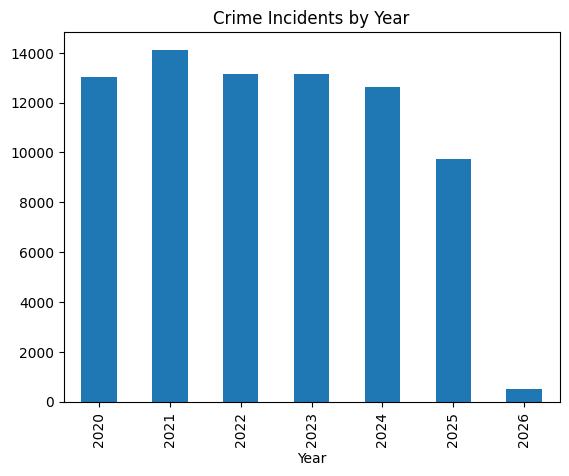

In [7]:
crime_df["Year"].value_counts().sort_index().plot(kind="bar", title="Crime Incidents by Year")

<Axes: title={'center': 'Top 10 Crime Types'}, ylabel='OFFENSE_DESCRIPTION'>

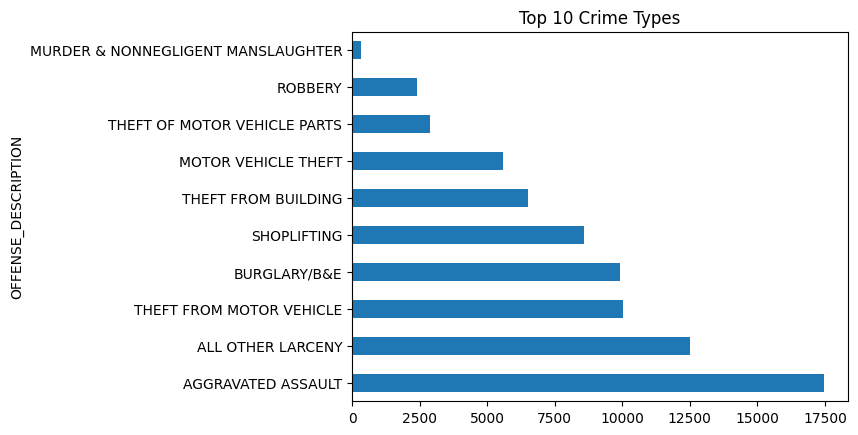

In [8]:
crime_df["OFFENSE_DESCRIPTION"].value_counts().head(10).plot(kind="barh", title="Top 10 Crime Types")

<Axes: >

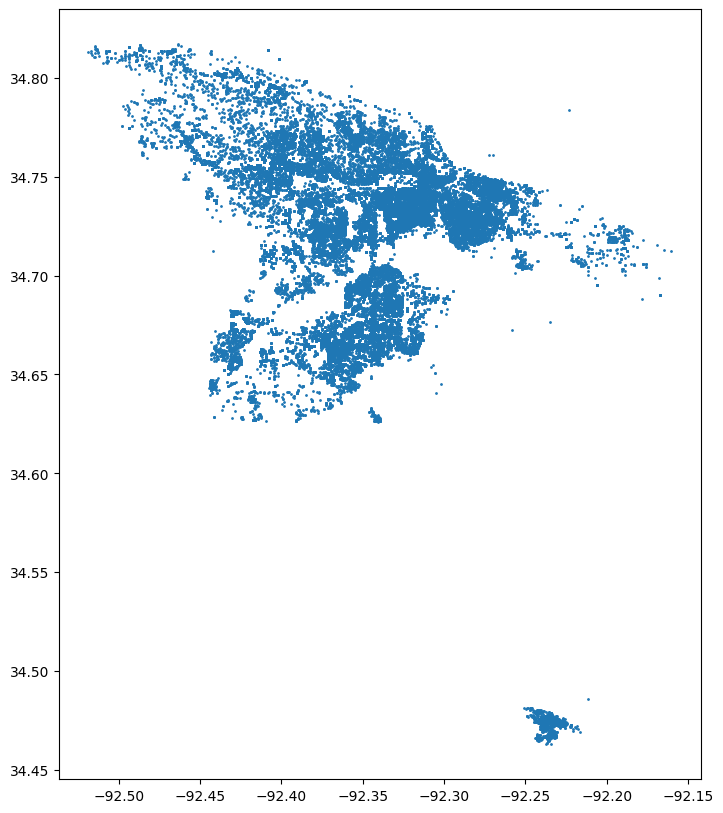

In [9]:
crime_gdf.plot(figsize=(10, 10), markersize=1)

In [10]:
crime_gdf.to_file("little_rock_crime.geojson", driver="GeoJSON")

In [11]:
from arcgis.gis import GIS
import getpass

def agol_login():
    print("Log in to ArcGIS Online")
    username = input("USERNAME: ")
    pwd = getpass.getpass("PASSWORD: ")
    gis = GIS("https://www.arcgis.com", username, pwd)
    print("Logged in as:", gis.properties.user.username)
    return gis

In [12]:
gis = agol_login()

Log in to ArcGIS Online
Logged in as: tangiha.majumder@wmich.edu


In [13]:
item_properties = {
    "title": "Little Rock Crime 2020 2026",
    "description": "Crime incidents in Little Rock created from CSV and converted to GeoJSON for GIS Programming mini project.",
    "tags": "GEOG6670, crime, Little Rock, ArcGIS Online",
    "type": "GeoJson"
}

geojson_file_path = "little_rock_crime.geojson"

geojson_item = gis.content.add(item_properties=item_properties, data=geojson_file_path)

published_layer = geojson_item.publish()

published_layer

C:\Users\tangi\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3701: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\tangi\AppData\Roaming\Python\Python313\site-packages\arcgis\graph\data_model_types.py:68: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class GraphProperty(BaseModel):
C:\Users\tangi\AppData\Roaming\Python\Python313\site-packages\arcgis\graph\data_model_types.py:271: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class FieldIndex(BaseModel):
C:\Users\tangi\Ap

<Item title:"Little Rock Crime 2020 2026" type:Feature Layer Collection owner:tangiha.majumder@wmich.edu>

In [15]:
webmap_item = crime_map.save({
    "title": "Little Rock Crime Web Map",
    "snippet": "Web map for GIS Programming mini project",
    "tags": ["crime", "Little Rock", "ArcGIS Online", "GEOG6670"]
})